In [3]:
import pandas as pd
df = pd.read_csv("/email_dataset_classification.csv", on_bad_lines='skip', engine='python')

In [4]:
#Dataset Overview

df.info()
df.shape
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6244 entries, 0 to 6243
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6244 non-null   int64 
 1   message     6244 non-null   object
 2   label       6244 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 146.5+ KB


,Unnamed: 0,message,label
0,0,['Fabulous discounts from CanadianPharmacy. 50...,1
1,1,http://houston.cowparade.net/,0
2,2,=================================\n\nGuarantee...,1
3,3,Thanks for your help! ---------------------- ...,0
4,4,Start Date: 10/13/01; HourAhead hour: 23; No a...,0


In [5]:
#Missing Values Check

df.isnull().sum()

,0
Unnamed: 0,0
message,0
label,0


In [6]:
#Class Distribution (VERY IMPORTANT for spam data)

df['label'].value_counts()

,count
label,
0,4371
1,1873


In [7]:
#Text Length Analysis

df['text_length'] = df['message'].apply(len)

df['text_length'].describe()

,text_length
count,6244.000000
mean,1418.868834
std,3094.882690
min,2.000000
25%,286.000000
50%,656.000000
75%,1473.250000
max,90127.000000


<Axes: xlabel='label', ylabel='count'>

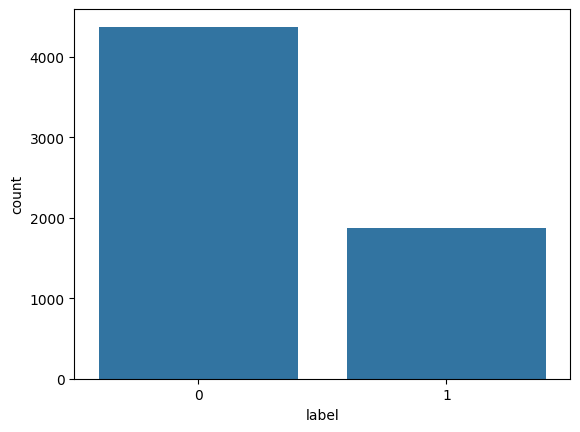

In [8]:
#Visualizations

#Class Distribution

import seaborn as sns
sns.countplot(x='label', data=df)

<Axes: xlabel='text_length', ylabel='Count'>

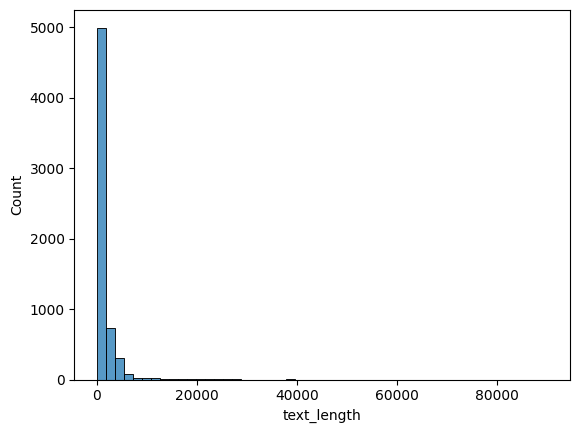

In [9]:
#Text Length Distribution

sns.histplot(df['text_length'], bins=50)

In [13]:
#Most Common Words
import re
from collections import Counter

# Basic Cleaning Function (moved here to resolve NameError)
def clean_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['message'].apply(clean_text)

all_words = ' '.join(df['clean_text']).split()
common_words = Counter(all_words).most_common(20)
print(common_words)

[('the', 49527), ('to', 34825), ('and', 23810), ('of', 22614), ('a', 19391), ('in', 15704), ('you', 13516), ('for', 13420), ('is', 11745), ('i', 10666), ('on', 9930), ('this', 9333), ('that', 9151), ('be', 7606), ('with', 7359), ('your', 6966), ('it', 6523), ('from', 6443), ('have', 6192), ('as', 6050)]


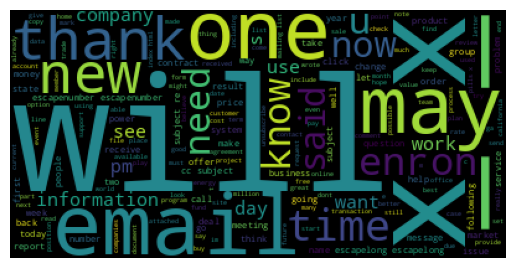

In [14]:
#WordCloud (Optional but good for presentation)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud().generate(' '.join(df['clean_text']))

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [16]:
#import required library

import re
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
#Basic Cleaning Function

def clean_text(text):
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [18]:
#Apply Cleaning

df['clean_text'] = df['message'].apply(clean_text)

In [19]:
#Remove Stopwords

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    return ' '.join([word for word in words if word not in stop_words])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [20]:
#Tokenization (Split into words)

import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

df['tokens'] = df['clean_text'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [21]:
#Stemming (Optional but useful)

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stemming(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

df['clean_text'] = df['clean_text'].apply(stemming)

In [22]:
# Final Output Check

df[['message', 'clean_text']].head()

,message,clean_text
0,['Fabulous discounts from CanadianPharmacy. 50...,fabul discount canadianpharmaci discount produ...
1,http://houston.cowparade.net/,
2,=================================\n\nGuarantee...,guarante increas lift firm breast day money ba...
3,Thanks for your help! ---------------------- ...,thank help tana joneshouect pm conni sutton pm...
4,Start Date: 10/13/01; HourAhead hour: 23; No a...,start date hourahead hour ancillari schedul aw...


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])

In [24]:
#Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
#Initialize TF-IDF

vectorizer = TfidfVectorizer(
    max_features=5000,   # limit vocabulary size
    ngram_range=(1,2),   # unigrams + bigrams
    min_df=2,            # ignore rare words
    max_df=0.8           # ignore very common words
)

In [26]:
#Fit and Transform Text

X = vectorizer.fit_transform(df['clean_text'])

In [27]:
#Check Output Shape

print(X.shape)

(6244, 5000)


In [28]:
#Convert to DataFrame (Optional, for inspection)

tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head()

,_____,________________________________,____________________________________,_____________________________________________,______________________________________________,______________________________________________ rhelpstatmathethzch,_______________________________________________,_______________________________________________ python,_______________________________________________ pythondev,_______________________________________________ speakup,...,young,your,youv,ze,zero,zip,zone,zoo,zvlllneumpythonorg,zvlllneumpythonorg unsubscrib
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
#Extract Target Variable

y = df['label']   # or 'spam', depending on your dataset

In [30]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
# Train a Baseline Model (Naive Bayes)

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

MultinomialNB()

In [32]:
#Make Predictions

y_pred = nb_model.predict(X_test)

In [33]:
#Evaluate Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9191353082465973

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       859
           1       0.96      0.78      0.86       390

    accuracy                           0.92      1249
   macro avg       0.93      0.88      0.90      1249
weighted avg       0.92      0.92      0.92      1249


Confusion Matrix:
 [[845  14]
 [ 87 303]]


In [34]:
#Try a Stronger Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Accuracy (LR):", accuracy_score(y_test, y_pred_lr))

Accuracy (LR): 0.9199359487590072


In [35]:
#Try Support Vector Machine (High Accuracy)

from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("Accuracy (SVM):", accuracy_score(y_test, y_pred_svm))

Accuracy (SVM): 0.9287429943955164


In [36]:
#Save the Model (Important)

import pickle

pickle.dump(lr_model, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('tfidf.pkl', 'wb'))

In [37]:
# Test with New Email

sample = ["Congratulations! You won a free lottery"]

sample_clean = [clean_text(sample[0])]
sample_vec = vectorizer.transform(sample_clean)

prediction = lr_model.predict(sample_vec)
print(prediction)

[0]


In [38]:
#Basic Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred, pos_label=1))

Accuracy: 0.9191353082465973
Precision: 0.9558359621451105
Recall: 0.7769230769230769
F1 Score: 0.8571428571428571


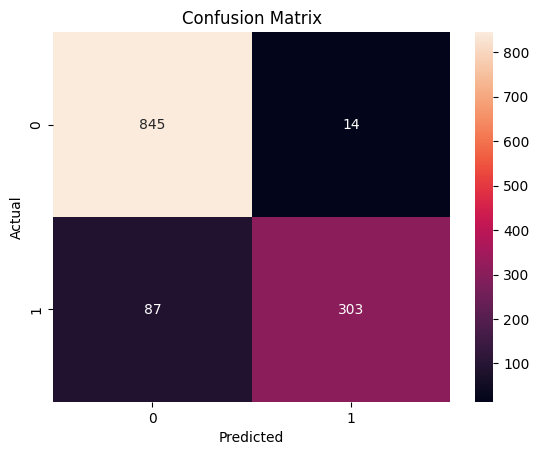

In [41]:
#Visualize Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

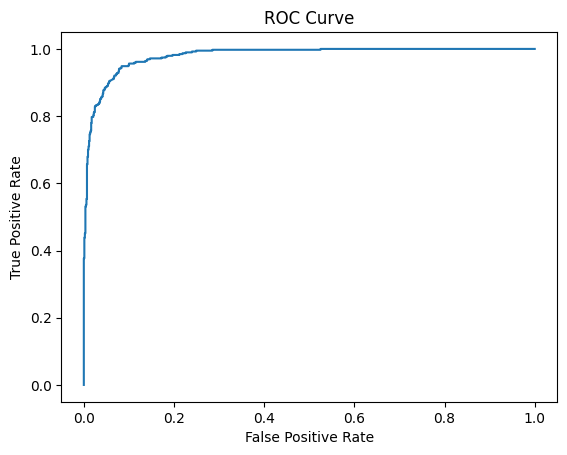

AUC Score: 0.980125966389063


In [42]:
# ROC Curve & AUC Score (Advanced)

from sklearn.metrics import roc_curve, auc

y_prob = lr_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc)

In [43]:
# predict_proba()   # for NB / LR
# decision_function()  # for SVM

In [44]:
print(y.value_counts())

label
0    4371
1    1873
Name: count, dtype: int64


In [45]:
#Reduce Dimensions (PCA → 2D)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

In [46]:
#Train Model on 2D Data

from sklearn.linear_model import LogisticRegression

model_2d = LogisticRegression()
model_2d.fit(X_reduced, y)

LogisticRegression()

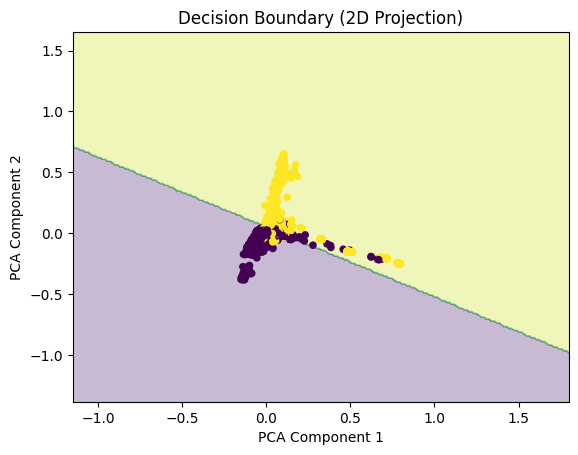

In [47]:
#Plot Decision Boundary

import numpy as np
import matplotlib.pyplot as plt

# Create grid
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict for grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, s=20)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Decision Boundary (2D Projection)")
plt.show()

In [49]:
#Get Most Common Words

from collections import Counter

all_words = ' '.join(df['clean_text'].dropna()).split()
common_words = Counter(all_words).most_common(20)

In [50]:
#Separate Words & Counts

words = [word for word, count in common_words]
counts = [count for word, count in common_words]

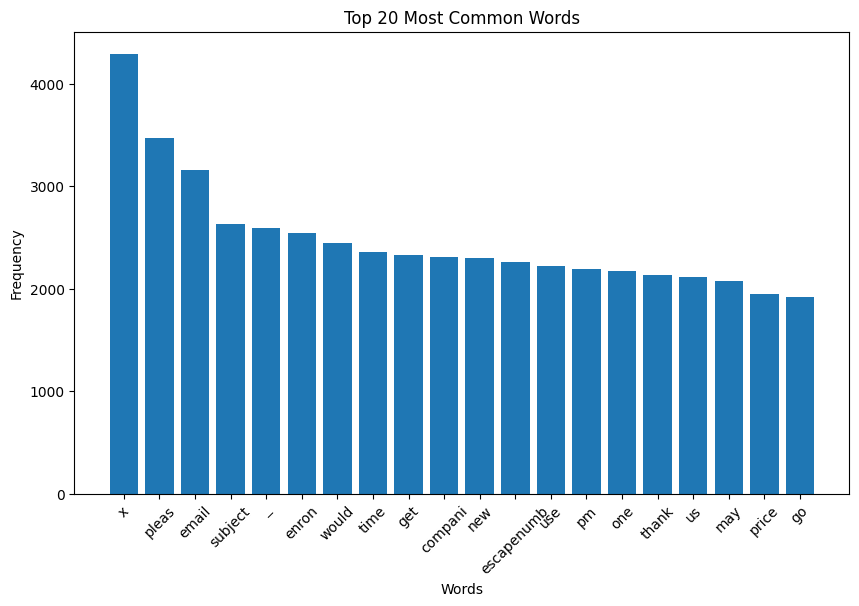

In [53]:
#Plot Bar Graph

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(words, counts)

plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Common Words")

plt.show()